Goal : Reproduce normalized SM vs BSM overlay distributions for key observables.

structure of the notebook
1. Imports
2. Load all datasets
3. Create helper functions
4. Normalize angular conventions
5. Plot overlay histograms
6. Compare observables
7. Physics observations

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
DATA_DIR = Path("../SMEFT_bbyy_h5files")

In [4]:
#-----------------------------
# loader function
#-----------------------------
def load_h5_to_df(filepath):

    with h5py.File(filepath, "r") as f:

        data = f["ForAnalysis/1d"][:]

    df = pd.DataFrame(data)

    return df

In [7]:
#----------------
#load all samples
#---------------
samples = {
    "SM": "new_input_bbyy_SMEFT_SM_4thMarch_2026.h5",
    "cbbim": "new_input_bbyy_SMEFT_cbbim_4thMarch_2026.h5",
    "cbgim": "new_input_bbyy_SMEFT_cbgim_4thMarch_2026.h5",
    "cbhim": "new_input_bbyy_SMEFT_cbhim_4thMarch_2026.h5",
    "chbtil": "new_input_bbyy_SMEFT_chbtil_4thMarch_2026.h5",
    "chgtil": "new_input_bbyy_SMEFT_chgtil_4thMarch_2026.h5",
    "ctbim": "new_input_bbyy_SMEFT_ctbim_4thMarch_2026.h5"
}

In [8]:
#--------------
#load into dictionary
#--------------
dfs = {}

for label, filename in samples.items():

    filepath = DATA_DIR / filename

    dfs[label] = load_h5_to_df(filepath)

    print(f"Loaded {label}")

Loaded SM
Loaded cbbim
Loaded cbgim
Loaded cbhim
Loaded chbtil
Loaded chgtil
Loaded ctbim


In [9]:
dfs["SM"]
dfs["chgtil"]

,DPhi_bb,DPhi_yybb,Eta_jj,Eta_yybb,EventNumber,Higgs_Eta,Higgs_Mass,Higgs_Phi,Higgs_pT,LeadJet_Eta,...,costheta1,costheta2,is_HHEvent,is_SingleHiggsEvent,is_SingleZEvent,is_ZHEvent,m_bbyy,nBTaggedJets,pT_jj,signed_DeltaPhi_jj
0,3.119000,2.514608,-2.507796,-2.494413,0,-0.416441,117.656502,1.060194,12.596146,-2.076296,...,-0.580704,0.795761,False,False,False,False,467.754791,2,102.264122,2.424838
1,2.035710,1.732308,-0.348214,-0.913484,0,-0.292749,134.536270,2.031302,155.009750,-1.035657,...,-0.761976,0.119400,False,False,False,False,359.722687,2,113.302933,0.666791
2,2.617405,1.146994,-2.675055,-3.578496,0,-0.541582,124.470871,-1.636987,32.896633,-2.122896,...,-0.275573,0.780797,True,False,False,False,351.319550,2,55.051300,3.304803
3,2.283491,0.131825,-1.490588,-2.846984,0,-2.265243,124.789124,-0.088654,55.922909,-1.648772,...,-0.708740,0.220208,True,False,False,False,289.979675,2,113.264648,5.133918
4,2.696344,-0.973482,1.543822,1.580898,0,-0.609448,124.776840,-2.218665,31.932432,0.218898,...,-0.066691,-0.530393,False,True,False,False,340.941437,2,91.903542,0.888842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67429,1.071224,-2.908705,-0.591299,-1.500953,0,-0.359596,126.463943,-1.647439,295.008057,-0.346382,...,0.594924,0.413492,True,False,False,False,551.113159,2,210.000366,5.400392
67430,1.917914,-2.208619,0.654727,2.433940,0,0.706616,126.237503,0.689681,203.875748,0.708019,...,0.884539,0.625905,False,True,False,False,423.042145,2,180.826553,0.331313
67431,2.929497,1.002507,-2.096495,-3.981260,0,-2.250131,125.102692,-2.965289,80.540474,-1.422858,...,-0.985803,0.235195,True,False,False,False,314.895569,2,107.666710,4.592269
67432,1.617334,1.459650,-0.523991,-1.876102,0,-1.216344,126.861084,-0.545565,156.449249,-0.780052,...,0.469968,0.000004,False,True,False,False,299.194458,2,95.084343,0.253107


In [10]:
#---------------
#fix the sign of signed_deltaphi_jj
#----------------
for label, df in dfs.items():

    df["signed_DeltaPhi_jj_centered"] = np.where(
        df["signed_DeltaPhi_jj"] > np.pi,
        df["signed_DeltaPhi_jj"] - 2*np.pi,
        df["signed_DeltaPhi_jj"]
    )

In [13]:
#--------------------------------------------
#general overlay plot function
#-------------------------------------------
def plot_overlay(
    dfs,
    observable,
    bins=50,
    x_label=None,
    title=None,
    x_range=None
):

    plt.figure(figsize=(8,6))

    for label, df in dfs.items():

        plt.hist(
            df[observable],
            bins=bins,
            range=x_range,
            density=True,
            histtype="step",
            linewidth=2,
            label=label
        )

    plt.xlabel(x_label if x_label else observable)

    plt.ylabel("Normalized Events")

    plt.title(title if title else observable)

    if x_range is not None:
        plt.xlim(x_range)

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

```
density=True
```
This performs:
area normalization.
```
histtype="step"
```
Cleaner HEP-style plots.

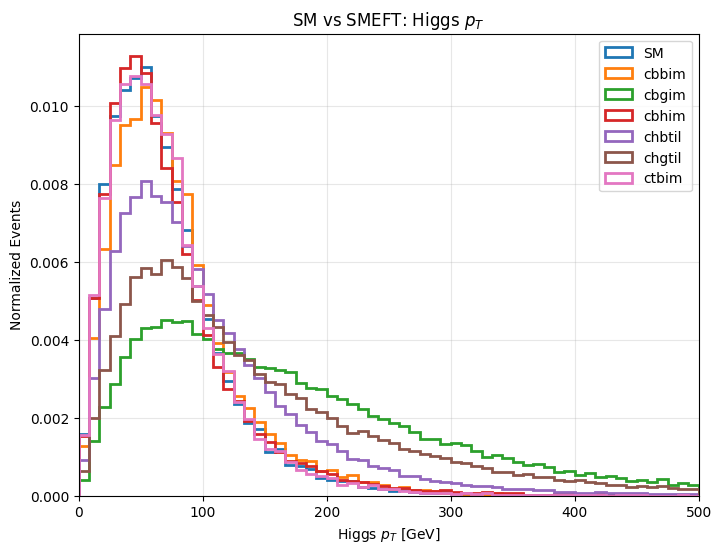

In [14]:
plot_overlay(
    dfs,
    observable="Higgs_pT",
    bins=60,
    x_range=(0, 500),
    x_label=r"Higgs $p_T$ [GeV]",
    title=r"SM vs SMEFT: Higgs $p_T$"
)

Observations: Higgs_pT
- The SM distribution falls steeply with increasing transverse momentum, as expected for standard hadron-collider production.
- Most EFT operators show visible distortions in the boosted high-$p_T$ region.
- Operators such as `chgtil` and `cbhim` exhibit enhanced tails at larger Higgs transverse momentum.
- Deviations between SM and BSM hypotheses become increasingly pronounced above $\sim 200$ GeV.

Interpretation:
This behaviour suggests that several EFT operators modify the production dynamics of the Higgs system, preferentially enhancing higher-energy event configurations. Since EFT contributions generally grow with energy scale, boosted regions become particularly sensitive to BSM effects.

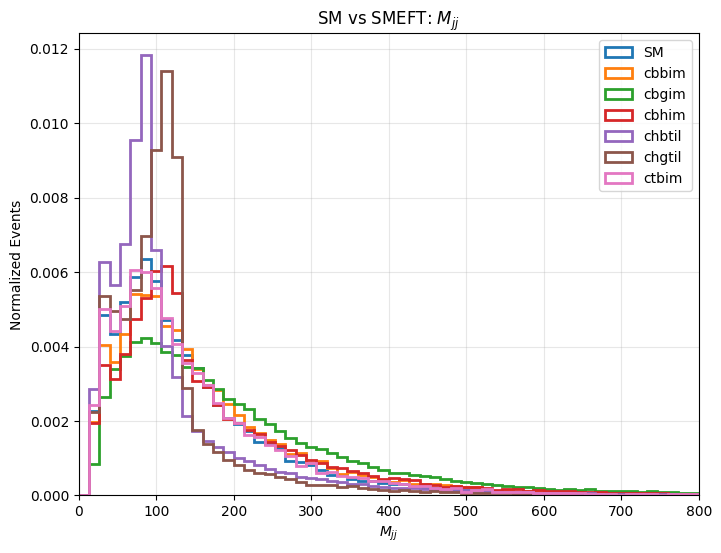

In [16]:
plot_overlay(
    dfs,
    observable="M_jj",
    bins=60,
    x_range=(0,800),
    x_label=r"$M_{jj}$",
    title=r"SM vs SMEFT: $M_{jj}$"
)

Observations: M_jj
- The SM distribution shows a broad peak structure associated with the reconstructed dijet system.
- Most EFT operators preserve the general peak location but modify the shape and tail behaviour.
- Some BSM samples exhibit broader high-mass tails relative to the SM expectation.
- Shape distortions are more visible at larger dijet invariant masses.

Interpretation:
The observable $M_{jj}$ probes the reconstructed $H \to bb$ decay system. EFT operators can alter jet kinematics and angular correlations, leading to modified invariant-mass distributions and enhanced high-energy tails.

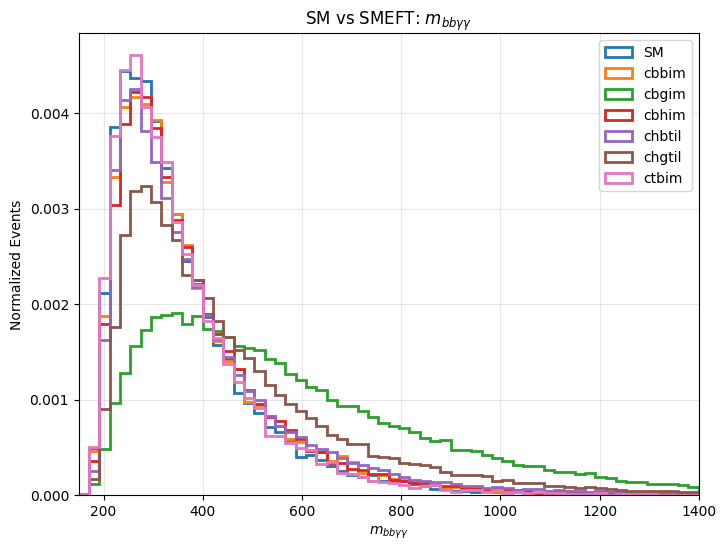

In [18]:
plot_overlay(
    dfs,
    observable="m_bbyy",
    bins=60,
    x_range=(150,1400),
    x_label=r"$m_{bb\gamma\gamma}$",
    title=r"SM vs SMEFT: $m_{bb\gamma\gamma}$"
)

Observations: m_bbyy
- The SM distribution decreases rapidly with increasing invariant mass of the full $bb\gamma\gamma$ system.
- Several EFT operators enhance the population of events in the large-$m_{bb\gamma\gamma}$ region.
- Differences between SM and BSM hypotheses become increasingly visible at higher invariant masses.
- Certain operators generate noticeably harder spectra compared to the SM sample.

Interpretation:
The invariant mass of the full final-state system is highly sensitive to new physics contributions. In SMEFT analyses, operator-induced effects typically grow with energy scale, making the high-mass tail one of the most important regions for identifying deviations from SM behaviour.

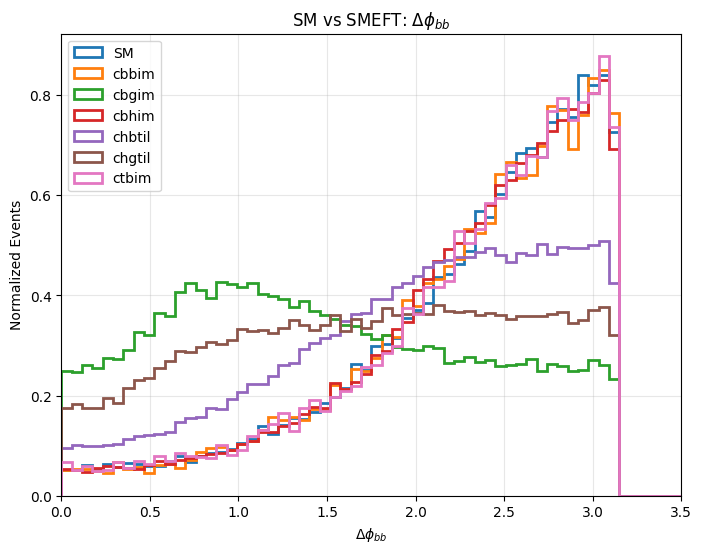

In [22]:
plot_overlay(
    dfs,
    observable="DPhi_bb",
    bins=60,
    x_range=(0,3.5),
    x_label=r"$\Delta\phi_{bb}$",
    title=r"SM vs SMEFT: $\Delta\phi_{bb}$"
)

Observations: DPhi_bb
- The SM distribution shows a strong preference for large angular separations between the two b-jets.
- Events cluster near approximately back-to-back configurations.
- EFT operators slightly distort the angular structure and modify the relative population across angular regions.
- Some BSM samples exhibit broader angular distributions compared to the SM.

Interpretation:
$\Delta\phi_{bb}$ encodes geometric information about the Higgs decay topology. Modifications to spin correlations, production kinematics, or CP structure can alter the angular separation between reconstructed jets.

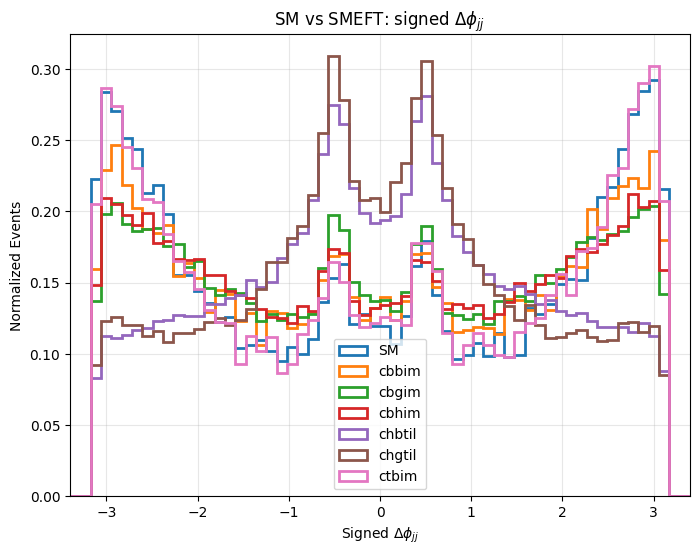

In [28]:
plot_overlay(
    dfs,
    observable="signed_DeltaPhi_jj_centered",
    bins=60,
    x_range=(-3.4,3.4),
    x_label=r"Signed $\Delta\phi_{jj}$",
    title=r"SM vs SMEFT: signed $\Delta\phi_{jj}$"
)

Observations: signed_DeltaPhi_jj_centered
- After recentering the observable into the interval $[-\pi, +\pi]$, the SM distribution appears approximately symmetric around zero.
- Several EFT operators introduce visible distortions in the angular structure.
- Certain BSM samples exhibit mild left-right asymmetries relative to the SM expectation.
- Deviations are particularly noticeable in regions away from $\Delta\phi_{jj} \approx 0$.

Interpretation:
This observable is the primary CP-sensitive variable in the analysis. Approximate symmetry in the SM sample is consistent with CP conservation, while asymmetries or directional distortions in EFT samples may indicate CP-violating contributions introduced by specific operators.

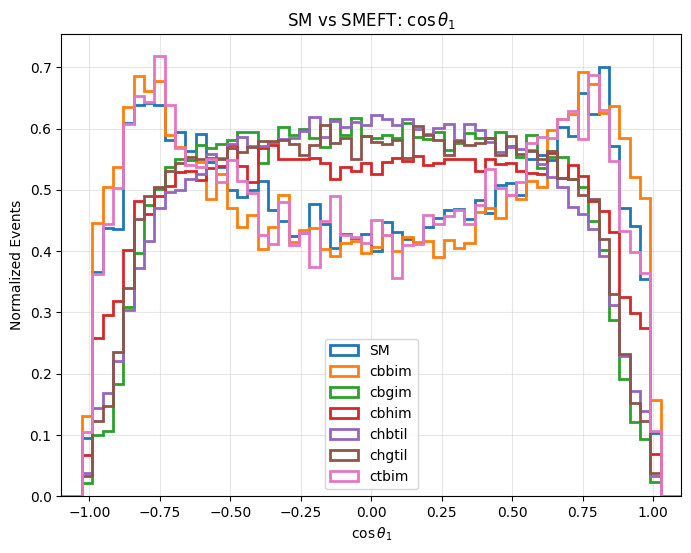

In [26]:
plot_overlay(
    dfs,
    observable="costheta1",
    bins=60,
    x_range=(-1.1,1.1),
    x_label=r"$\cos\theta_1$",
    title=r"SM vs SMEFT: $\cos\theta_1$"
)

Observations: costheta1
- The SM distribution exhibits non-trivial angular structure across the allowed interval $[-1,1]$.
- EFT operators modify the relative population of central and edge regions.
- Several BSM hypotheses show shape distortions compared to the SM expectation.
- Differences are more visible in regions corresponding to extreme decay angles.

Interpretation:
The variable $\cos\theta_1$ probes helicity structure and decay geometry in the Higgs rest frame. EFT operators affecting CP structure or spin correlations can alter the angular distribution of the decay products, producing measurable deviations from the Standard Model prediction.

In [32]:
#------------------------------------------------------
#sketch the exact plots of figure 12
#-----------------------------------------------------
observables_to_plot = [

    "Higgs_pT",
    "Higgs_Mass",
    "LeadPhoton_pT",
    "m_bbyy",
    "SubLeadPhoton_pT",
    "M_jj",
    "DPhi_bb",
    "signed_DeltaPhi_jj_centered",
    "costheta1",
    "LeadJet_pT",
    "LeadJet_M",
    "pT_jj"
]

In [35]:
plot_configs = {

    "Higgs_pT": {
        "range": (0, 500),
        "xlabel": r"$p_T^H$ [GeV]"
    },

    "Higgs_Mass": {
        "range": (115, 135),
        "xlabel": r"$m_H$ [GeV]"
    },

    "m_bbyy": {
        "range": (180, 1420),
        "xlabel": r"$m_{bb\gamma\gamma}$ [GeV]"
    },

    "signed_DeltaPhi_jj_centered": {
        "range": (-np.pi, np.pi),
        "xlabel": r"Signed $\Delta\phi_{jj}$"
    },

    "costheta1": {
        "range": (-1, 1),
        "xlabel": r"$\cos\theta_1$"
    },

    "LeadJet_M": {
        "range": (0,45),
        "xlabel": r"LeadJet_M"
    },

    "LeadJet_pT": {
        "range": (0,400),
        "xlabel": r"LeadJet_pT"
    },

    "M_jj": {
        "range": (0,800),
        "xlabel": r"M_jj"
    },

    "SubLeadPhoton_pT": {
        "range": (25,175),
        "xlabel": r"SubLeadPhoton_pT"
    },

    "DPhi_bb": {
        "range": (0, 3.5),
        "xlabel": r"DPhi_bb"
    },

    "pT_jj": {
        "range": (0, 450),
        "xlabel": r"pT_jj"
    },

    "LeadPhoton_pT": {
        "range": (0, 400),
        "xlabel": r"LeadPhoton_pT"
    }
}

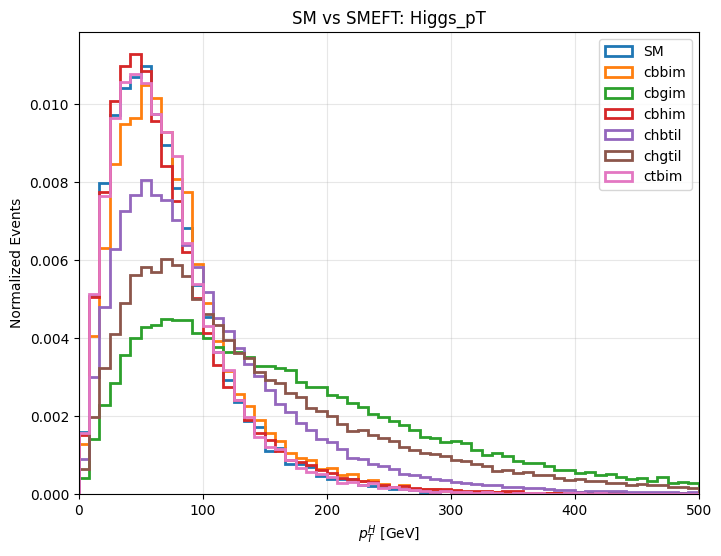

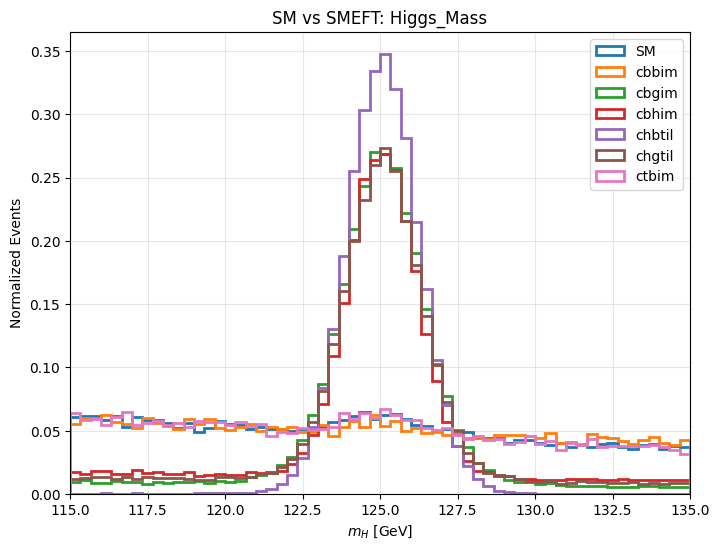

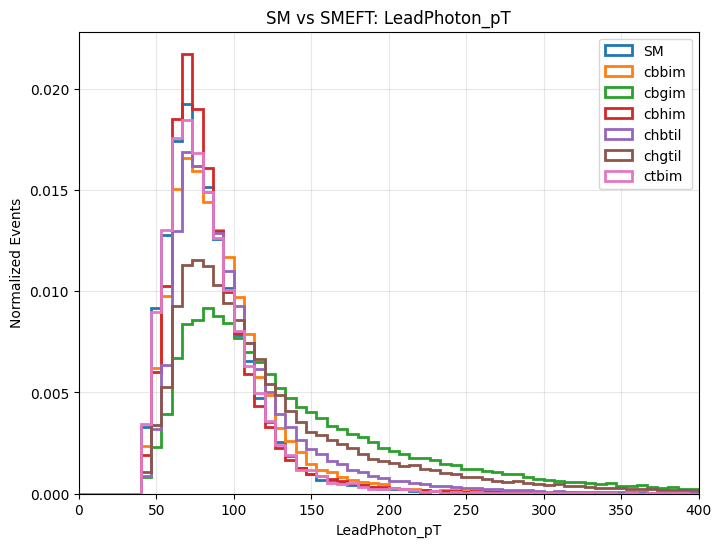

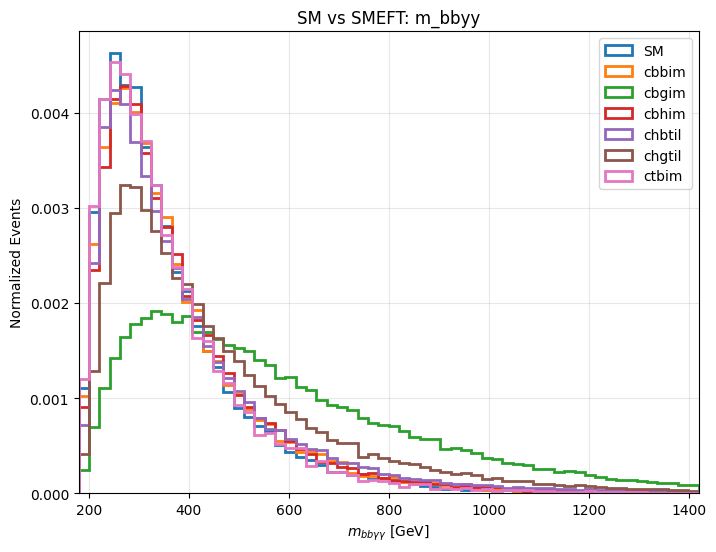

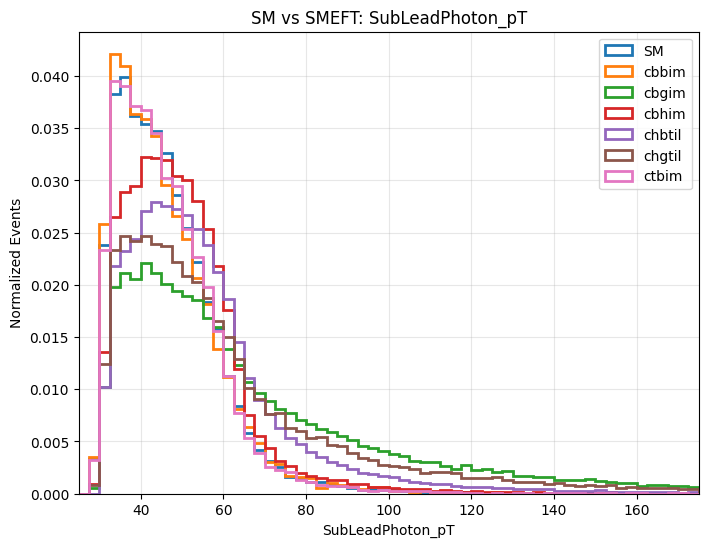

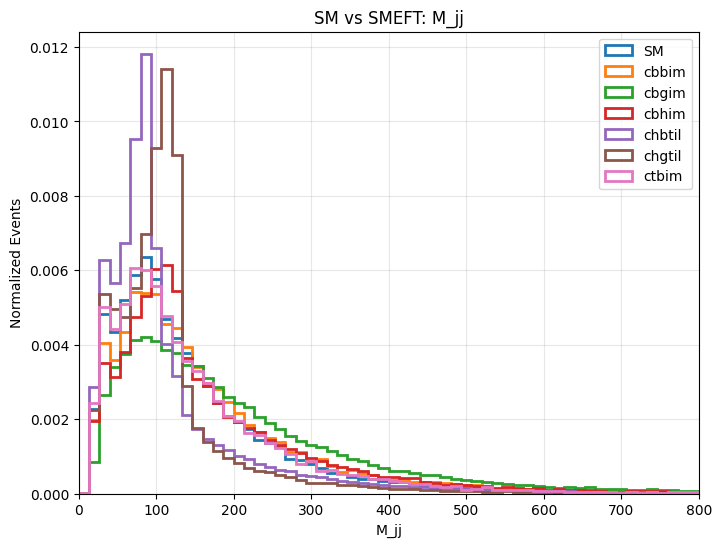

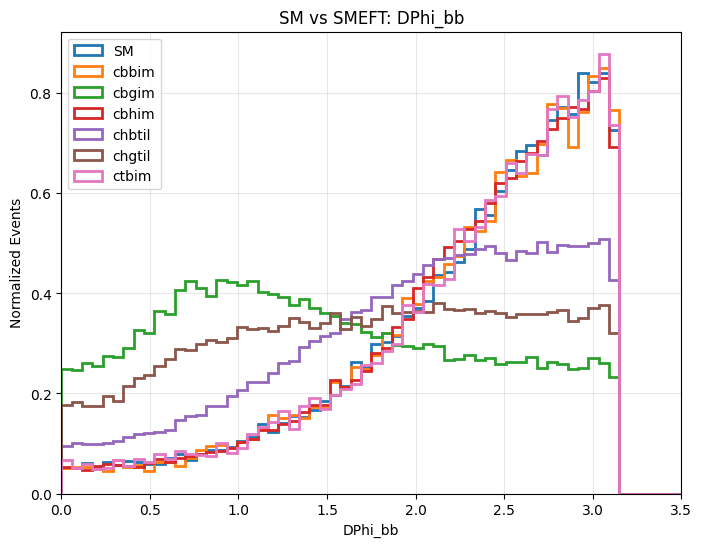

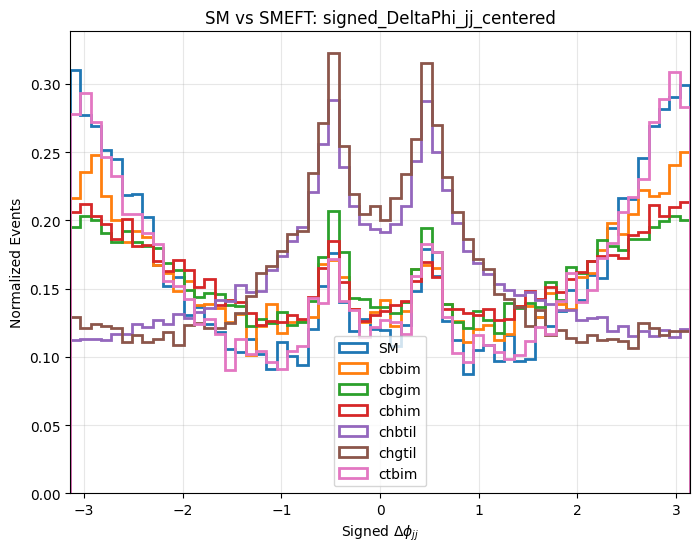

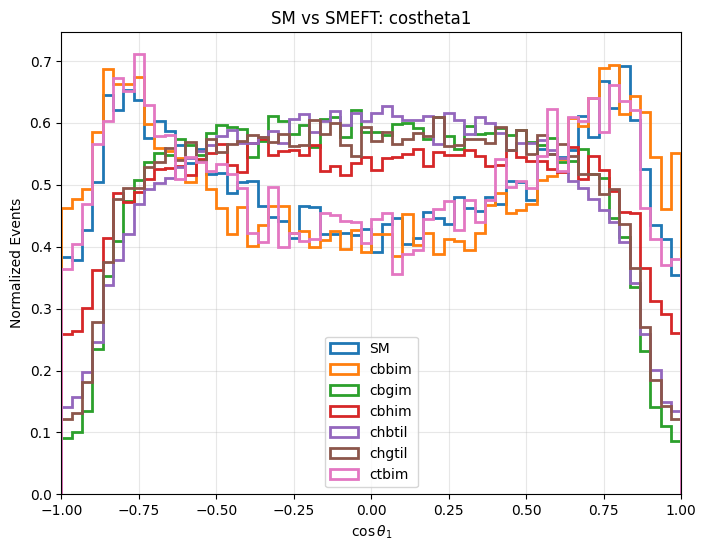

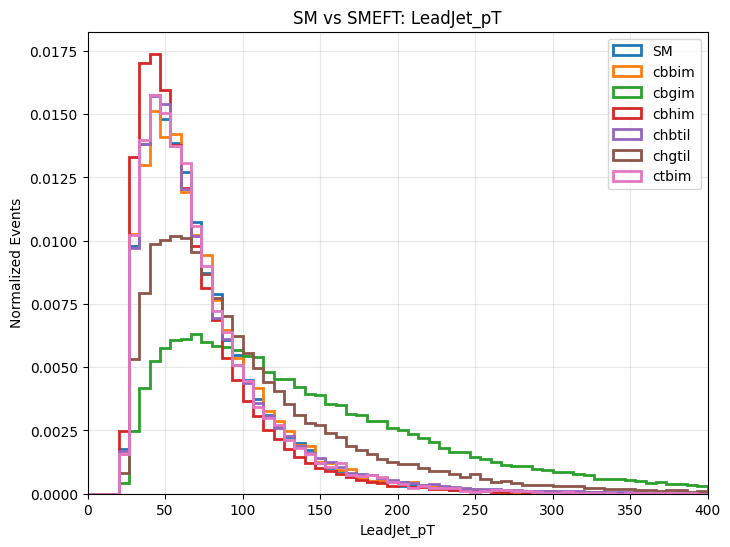

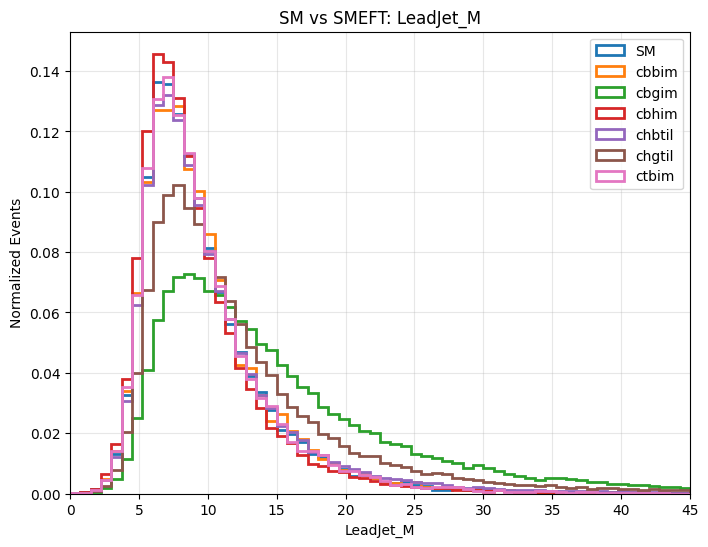

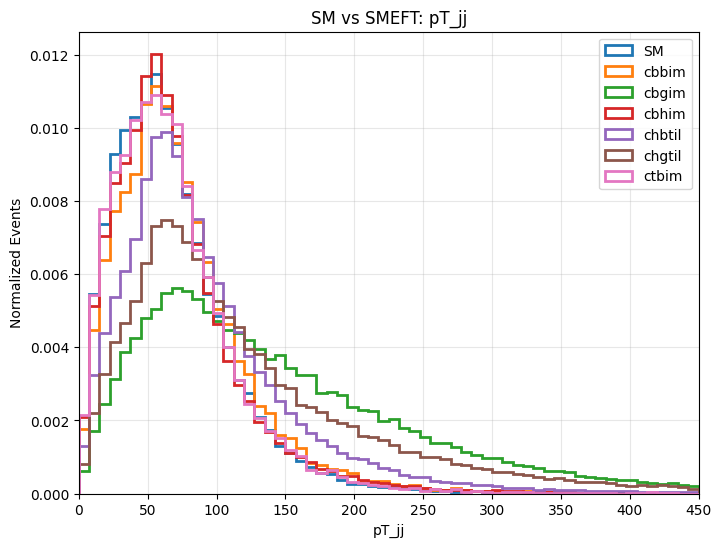

In [36]:
for obs in observables_to_plot:

    config = plot_configs.get(obs, {})

    plot_overlay(
        dfs,
        observable=obs,
        bins=60,
        x_range=config.get("range", None),
        x_label=config.get("xlabel", obs),
        title=f"SM vs SMEFT: {obs}"
    )

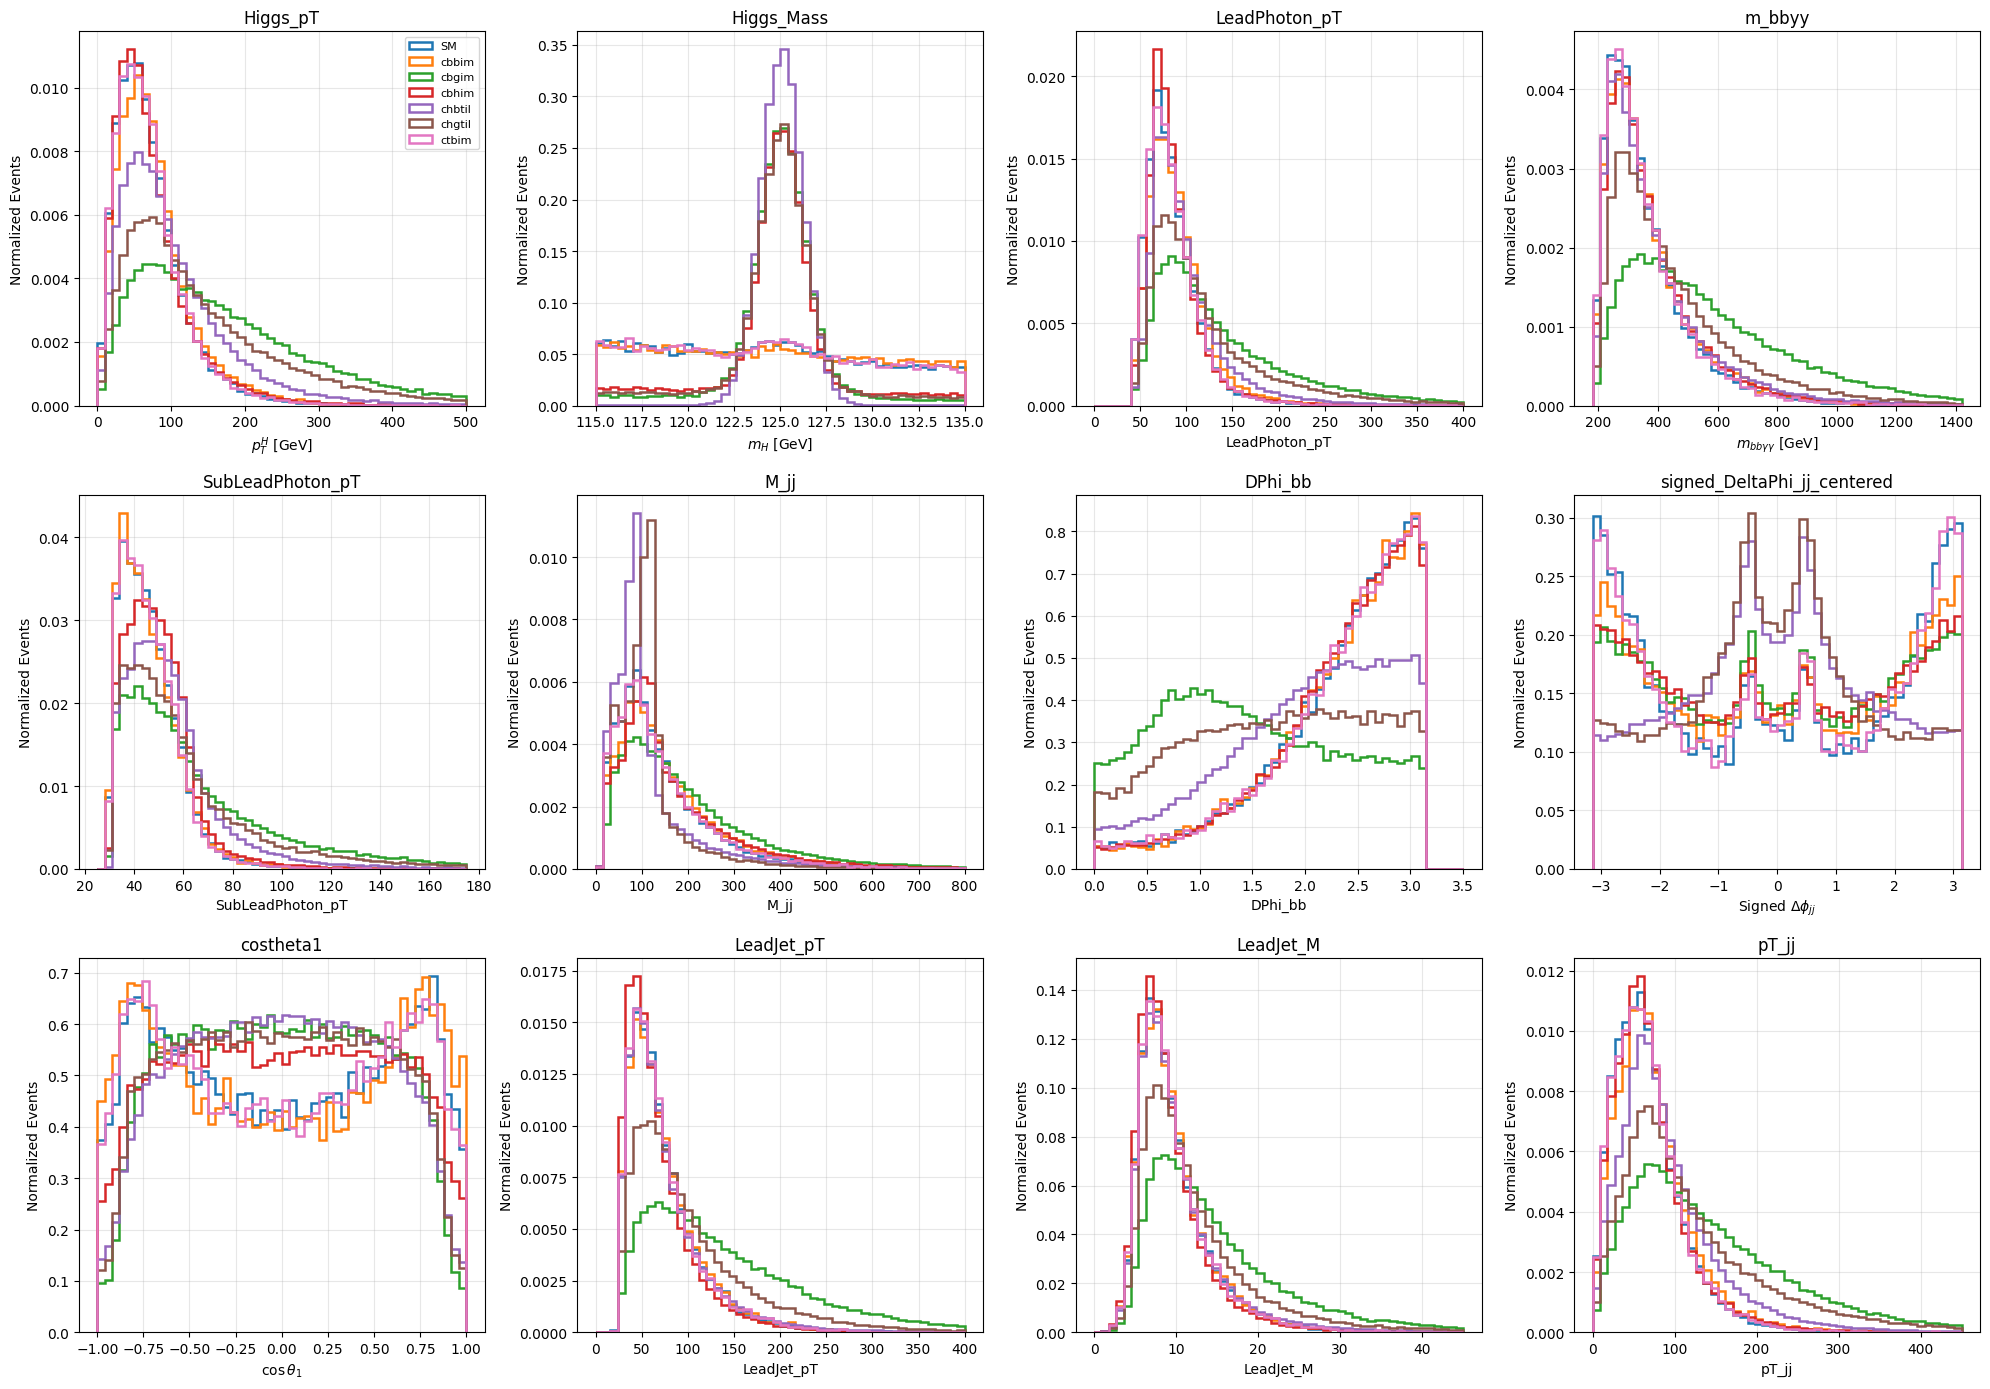

In [41]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(20, 14)
)

axes = axes.flatten()

for idx, observable in enumerate(observables_to_plot):

    ax = axes[idx]

    config = plot_configs[observable]

    for label, df in dfs.items():

        ax.hist(
            df[observable],
            bins=50,
            range=config["range"],
            density=True,
            histtype="step",
            linewidth=1.8,
            label=label
        )

    ax.set_xlabel(config["xlabel"])

    ax.set_ylabel("Normalized Events")

    ax.set_title(observable)

    ax.grid(alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()

plt.show()

In [42]:
def histogram_overlap(
    sm_values,
    bsm_values,
    bins=50,
    x_range=None
):

    sm_hist, edges = np.histogram(
        sm_values,
        bins=bins,
        range=x_range,
        density=True
    )

    bsm_hist, _ = np.histogram(
        bsm_values,
        bins=bins,
        range=x_range,
        density=True
    )

    overlap = np.sum(
        np.minimum(sm_hist, bsm_hist)
    )

    overlap *= (edges[1] - edges[0])

    return overlap

In [44]:
results = []

for observable in observables_to_plot:

    config = plot_configs[observable]

    for operator in dfs:

        if operator == "SM":
            continue

        overlap = histogram_overlap(

            dfs["SM"][observable],

            dfs[operator][observable],

            bins=50,

            x_range=config["range"]
        )

        results.append({

            "Observable": observable,
            "Operator": operator,
            "Overlap": overlap
        })

In [45]:
results_df = pd.DataFrame(results)

results_df.sort_values("Overlap")

,Observable,Operator,Overlap
9,Higgs_Mass,chbtil,0.317629
7,Higgs_Mass,cbgim,0.455576
10,Higgs_Mass,chgtil,0.483860
8,Higgs_Mass,cbhim,0.505934
1,Higgs_pT,cbgim,0.541772
...,...,...,...
17,LeadPhoton_pT,ctbim,0.981099
59,LeadJet_pT,ctbim,0.981572
29,SubLeadPhoton_pT,ctbim,0.981641
65,LeadJet_M,ctbim,0.981709


Lower overlap:
→ more discriminating observable.